## 06b — Extended Feature Extraction

Continues from `06_features.ipynb`. Adds advanced time/frequency features to the existing
80-column feature table, then splits into two datasets based on velocity regime.

### Pipeline
1. **Step 2 — Advanced Feature Extraction** (`extract_new_features`)
   - Loads existing `window_features.csv` and reconstructs raw windowed signals from `filtered_dataset.csv`
   - Overwrites `ax/ay/az kurtosis` and `ax/ay/az jerk_rms` using scipy / no-fs-scaling formulas
   - Adds 45 new columns: spectral entropy, dominant freq, spectral centroid, 40-80 Hz bandpower,
     Hjorth parameters (acc/acc_mag), kurtosis + jerk_rms + 40-80 Hz bandpower (gyro/gyro_mag),
     and three odometry statistics
   - Saves enriched table internally as `enriched_df` (125 feature cols)

2. **Step 1 — Velocity Filtering** (`create_velocity_filtered_dataset`)
   - **Dataset A**: all windows (no filtering)
   - **Dataset B**: windows where mean velocity < 0.5 m/s AND velocity std < 0.05 m/s

3. **Save** `data/processed/dataset_A_features.csv` and `dataset_B_features.csv`

In [1]:
from pathlib import Path
import sys

import pandas as pd

# Make project root importable whether CWD is repo root or notebooks/
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'src').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import (
    extract_new_features,
    create_velocity_filtered_dataset,
    run_feature_evaluation,
)

SAMPLE_RATE = 100  # Hz
ACC_COLS  = ['ax', 'ay', 'az']
GYRO_COLS = ['gx', 'gy', 'gz']
VEL_COL   = 'net_speed'

RANDOM_STATE = 42
TOP_N_HEATMAP = 20
TSNE_SAMPLE_CAP = 2500

# I/O paths
features_path  = PROJECT_ROOT / 'data' / 'processed' / 'window_features.csv'
windows_path   = PROJECT_ROOT / 'data' / 'processed' / 'windowed_metadata.csv'
filtered_path  = PROJECT_ROOT / 'data' / 'interim' / 'filtered' / 'filtered_dataset.csv'
cleaned_path   = PROJECT_ROOT / 'data' / 'interim' / 'cleaned'  / 'cleaned_dataset.csv'
output_dir     = PROJECT_ROOT / 'data' / 'processed'

reports_dir_a = PROJECT_ROOT / 'reports' / 'features' / 'dataset_A'
reports_dir_b = PROJECT_ROOT / 'reports' / 'features' / 'dataset_B'

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis


In [2]:
# ── Data loading ────────────────────────────────────────────────────────────
if not features_path.exists():
    raise FileNotFoundError(
        f'window_features.csv not found at {features_path}.\n'
        'Please run 06_features.ipynb first.'
    )
if not windows_path.exists():
    raise FileNotFoundError(
        f'windowed_metadata.csv not found at {windows_path}.\n'
        'Please run 05_windowing.ipynb first.'
    )

features_df = pd.read_csv(features_path, low_memory=False)
windows_df  = pd.read_csv(windows_path,  low_memory=False)

if filtered_path.exists():
    signal_path = filtered_path
    print('Using filtered dataset for feature extraction')
elif cleaned_path.exists():
    signal_path = cleaned_path
    print('Filtered dataset not found; falling back to cleaned dataset')
else:
    raise FileNotFoundError(
        'No source signal dataset found.\n'
        'Run 04_cleaning.ipynb and 04b_filtering.ipynb first.'
    )

signals_df = pd.read_csv(signal_path, low_memory=False)
signals_df = signals_df.sort_values(['run_id', 't_rel']).reset_index(drop=True)

# ── Validation ──────────────────────────────────────────────────────────────
missing_imu = [c for c in ACC_COLS + GYRO_COLS if c not in signals_df.columns]
if missing_imu:
    raise KeyError(f'Missing IMU columns in signals: {missing_imu}')
if VEL_COL not in signals_df.columns:
    raise KeyError(
        f"Velocity column '{VEL_COL}' not found. Available: {list(signals_df.columns)}"
    )
for col in ['window_id', 'run_id', 't_start', 't_end']:
    if col not in windows_df.columns:
        raise KeyError(f"Required column '{col}' missing from windowed_metadata.csv")

ID_COLS = ['window_id', 'run_id', 'segment_id', 'label', 't_start', 't_end', 'n_samples']
existing_feature_cols = [c for c in features_df.columns if c not in ID_COLS]

print(f'features_df shape:  {features_df.shape}  ({len(existing_feature_cols)} feature cols)')
print(f'windows_df  shape:  {windows_df.shape}')
print(f'signals_df  shape:  {signals_df.shape}')
print(f'Velocity column:    {VEL_COL}')

Using filtered dataset for feature extraction
features_df shape:  (1729, 202)  (195 feature cols)
windows_df  shape:  (1729, 9)
signals_df  shape:  (211705, 14)
Velocity column:    net_speed


## Step 2 — Advanced Feature Extraction

Helper functions + `extract_new_features`.

In [5]:
# ── Run extraction ───────────────────────────────────────────────────────────
print(f'Running extract_new_features on {len(windows_df)} windows...')
print('(Estimated time: 30-90 s at 100 Hz / 200 samples per window)')

new_features_df = extract_new_features(
    windows_df,
    signals_df,
    fs      = SAMPLE_RATE,
    vel_col = VEL_COL,
)
print(f'Done.  new_features_df shape: {new_features_df.shape}')

# ── Merge into enriched_df ───────────────────────────────────────────────────
# Columns to overwrite (same name, recomputed via scipy / updated formula)
OVERWRITE_COLS = [
    'ax_kurtosis', 'ay_kurtosis', 'az_kurtosis',
    'ax_jerk_rms', 'ay_jerk_rms', 'az_jerk_rms',
]

# Drop overwrite cols from original feature table before merging
features_base = features_df.drop(
    columns=[c for c in OVERWRITE_COLS if c in features_df.columns]
)

# Left-join on window_id: every existing window is retained
enriched_df = features_base.merge(new_features_df, on='window_id', how='left')

# Enforce column order: ID cols first, then all feature cols
id_present   = [c for c in ID_COLS if c in enriched_df.columns]
feat_present = [c for c in enriched_df.columns if c not in id_present]
enriched_df  = enriched_df[id_present + feat_present]

# ── Summary ──────────────────────────────────────────────────────────────────
n_before  = len(existing_feature_cols)
n_after   = len(feat_present)
n_overwr  = len(OVERWRITE_COLS)
n_new     = n_after - (n_before - n_overwr)

nan_counts  = enriched_df[feat_present].isna().sum()
total_nan   = int(nan_counts.sum())

print()
print('=' * 60)
print('FEATURE EXTRACTION SUMMARY')
print('=' * 60)
print(f'Features before extraction:             {n_before}')
print(f'Overwritten (recomputed, same name):    {n_overwr}')
print(f'New features added:                     {n_new}')
print(f'Features after extraction:              {n_after}')
print(f'Enriched DataFrame shape:               {enriched_df.shape}')
print(f'Total NaN values in feature cols:       {total_nan}')
if total_nan > 0:
    print('Columns with NaNs:')
    print(nan_counts[nan_counts > 0].sort_values(ascending=False).to_string())

Running extract_new_features on 1729 windows...
(Estimated time: 30-90 s at 100 Hz / 200 samples per window)
Done.  new_features_df shape: (1729, 52)

FEATURE EXTRACTION SUMMARY
Features before extraction:             195
Overwritten (recomputed, same name):    6
New features added:                     51
Features after extraction:              240
Enriched DataFrame shape:               (1729, 247)
Total NaN values in feature cols:       0


## Step 1 — Velocity Filtering and Dataset B Evaluation

Split the enriched dataset into:
- Dataset A — all windows
- Dataset B — low constant-velocity windows (odom_mean_velocity approx 0.5 m/s AND odom_vel_std < 0.1 m/s)

Then run the same feature evaluation pipeline used in 06_features on Dataset B and save outputs to reports/features/dataset_B/.

In [7]:
dataset_A, dataset_B = create_velocity_filtered_dataset(
    enriched_df,
    vel_col     = 'odom_mean_velocity',
    mean_thresh = 0.6,   # captures the low-speed cluster (~0.52 m/s); min in dataset is 0.476
    std_thresh  = 0.1,
    label_col   = 'label',
)

print(f'\nDataset A shape: {dataset_A.shape}')
print(f'Dataset B shape: {dataset_B.shape}')

DATASET A - Full Dataset
Total windows: 1729
Class distribution:
  dry_dirt_track                 652  (37.7%)
  grass                          386  (22.3%)
  muddy_dirt_track               145  (8.4%)
  smooth_terrain                 546  (31.6%)

DATASET B - Low Constant-Velocity Subset
  Criteria: odom_mean_velocity < 0.6 m/s  AND  odom_vel_std < 0.1 m/s
Windows kept:     1160  (67.1%)
Windows removed:   569  (32.9%)
Class distribution:
  dry_dirt_track                 523  (45.1%)
  grass                          354  (30.5%)
  muddy_dirt_track                75  (6.5%)
  smooth_terrain                 208  (17.9%)

Dataset A shape: (1729, 247)
Dataset B shape: (1160, 247)


Dataset A reports directory: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A
Dataset B reports directory: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B
Feature table diagnostics
Shape: (1160, 247)
Feature count: 240
Total missing values in feature columns: 0

Label distribution:
                  count    pct
label                         
dry_dirt_track      523  45.09
grass               354  30.52
muddy_dirt_track     75   6.47
smooth_terrain      208  17.93

Quick summary (key separator candidates):
                  acc_mag_rms  acc_mag_std  acc_mag_energy  gyro_mag_rms  gyro_mag_std  gyro_mag_energy
label                                                                                                  
dry_dirt_track         0.1125       0.0480          2.6655       11.6673        1.8413       27530.0115
grass                  0.1184       0.0498          2.858

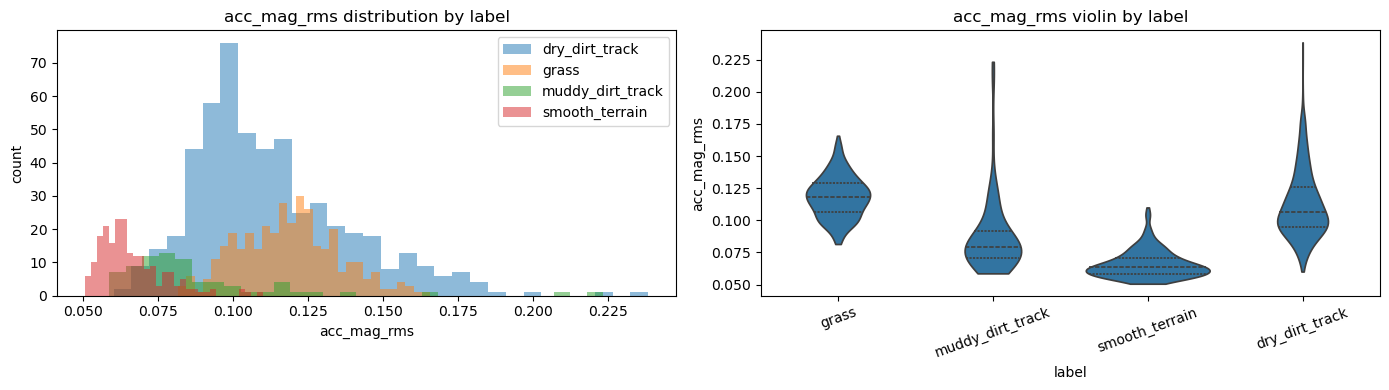

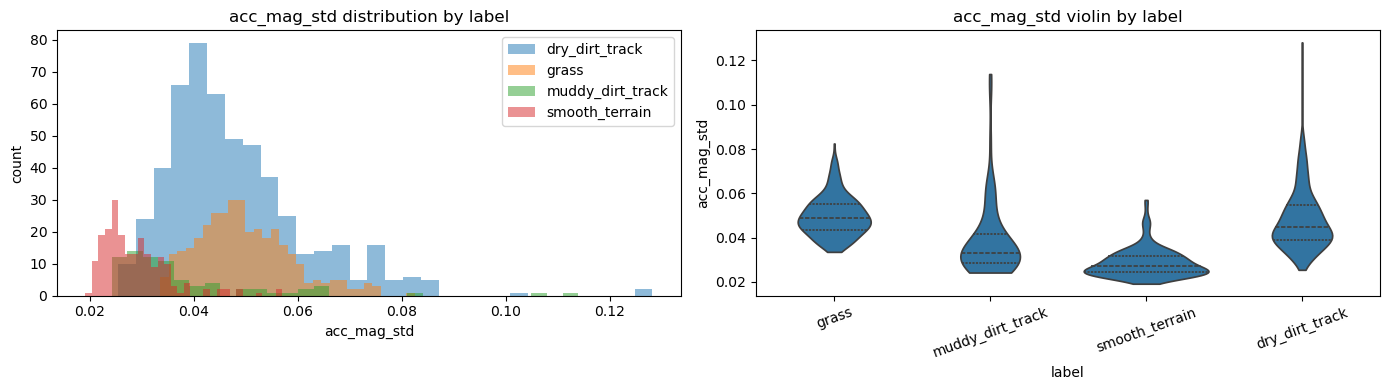

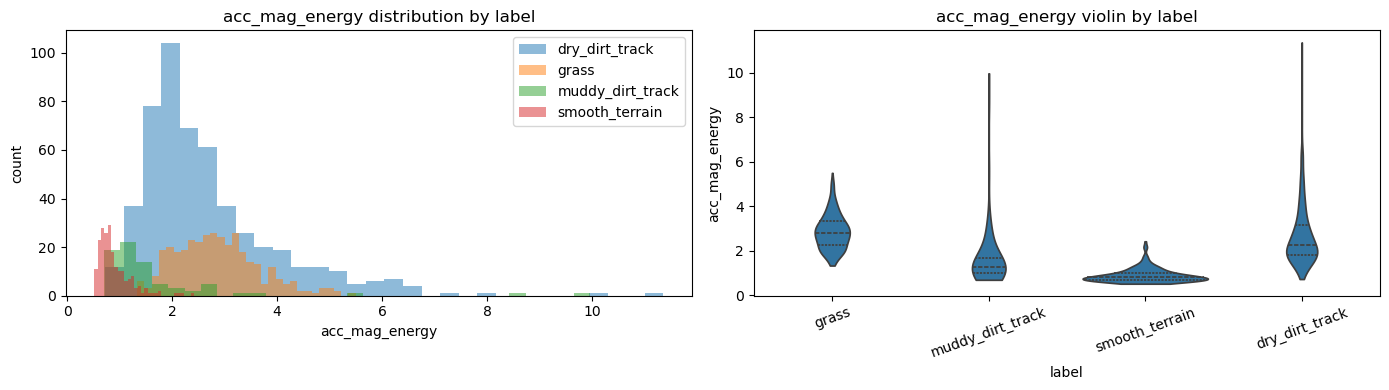

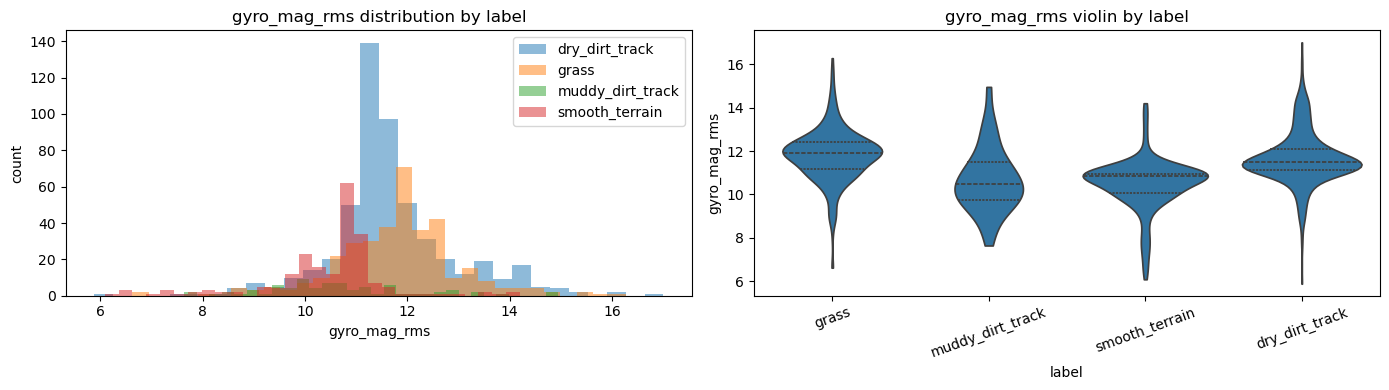

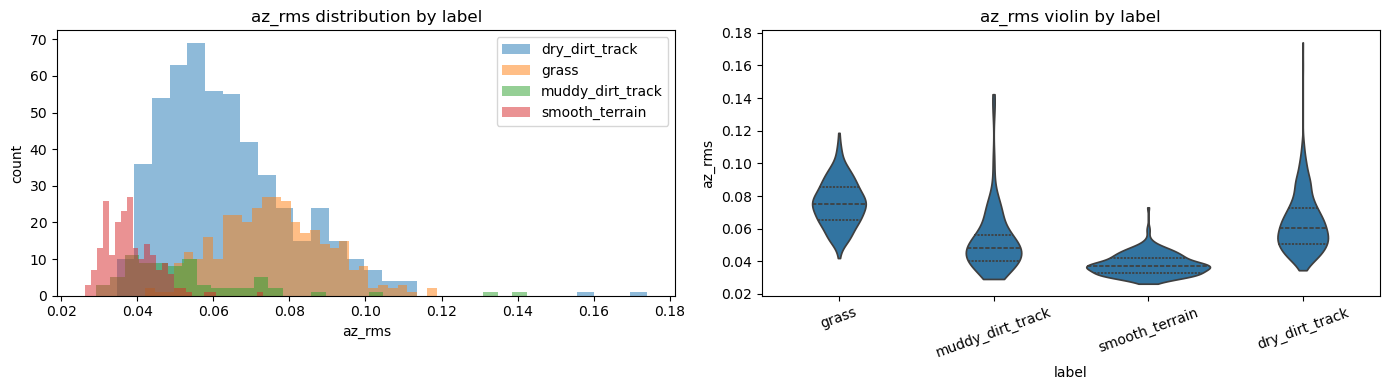

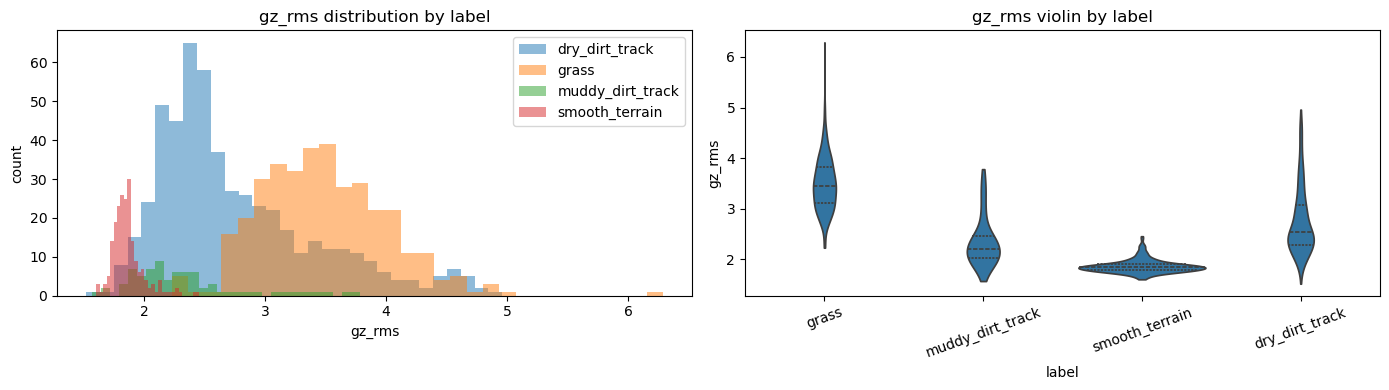

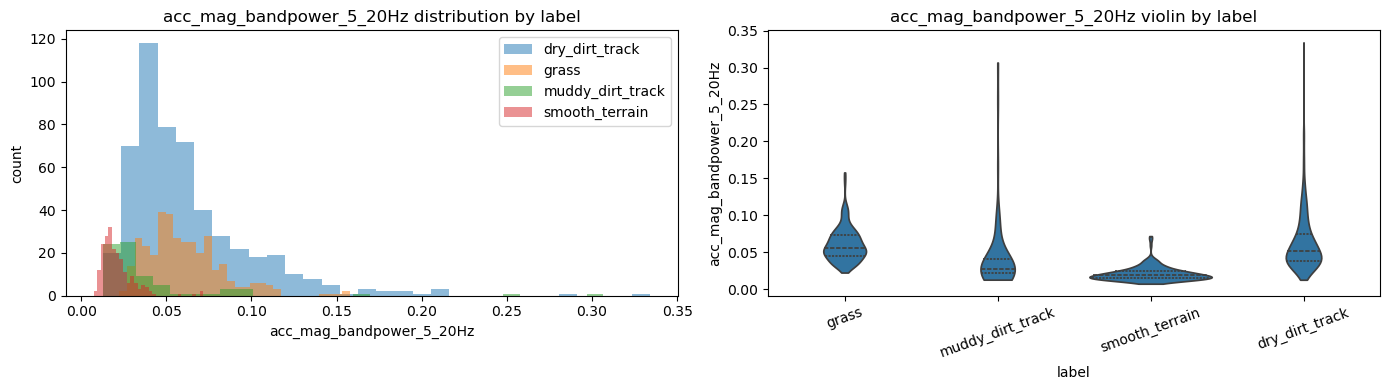

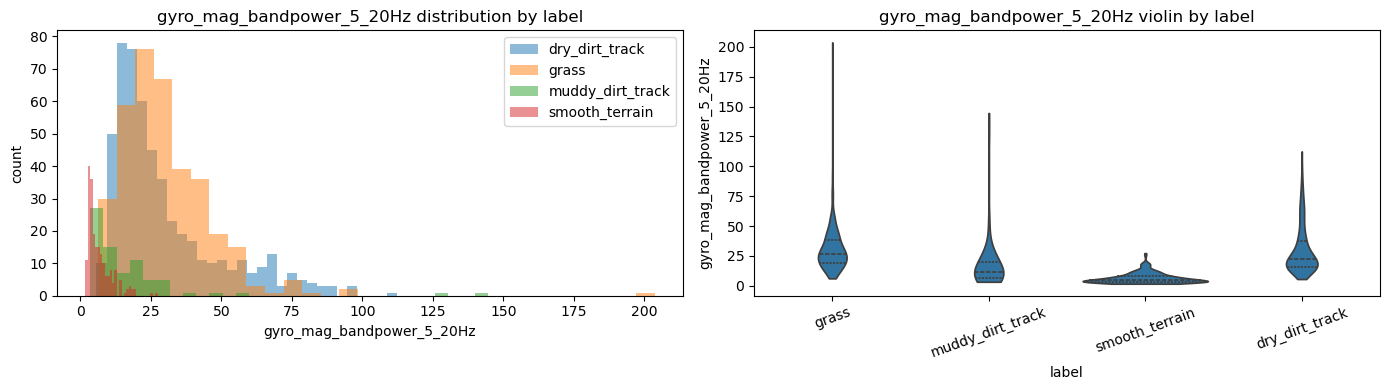

Saved 8 distribution figures to /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B


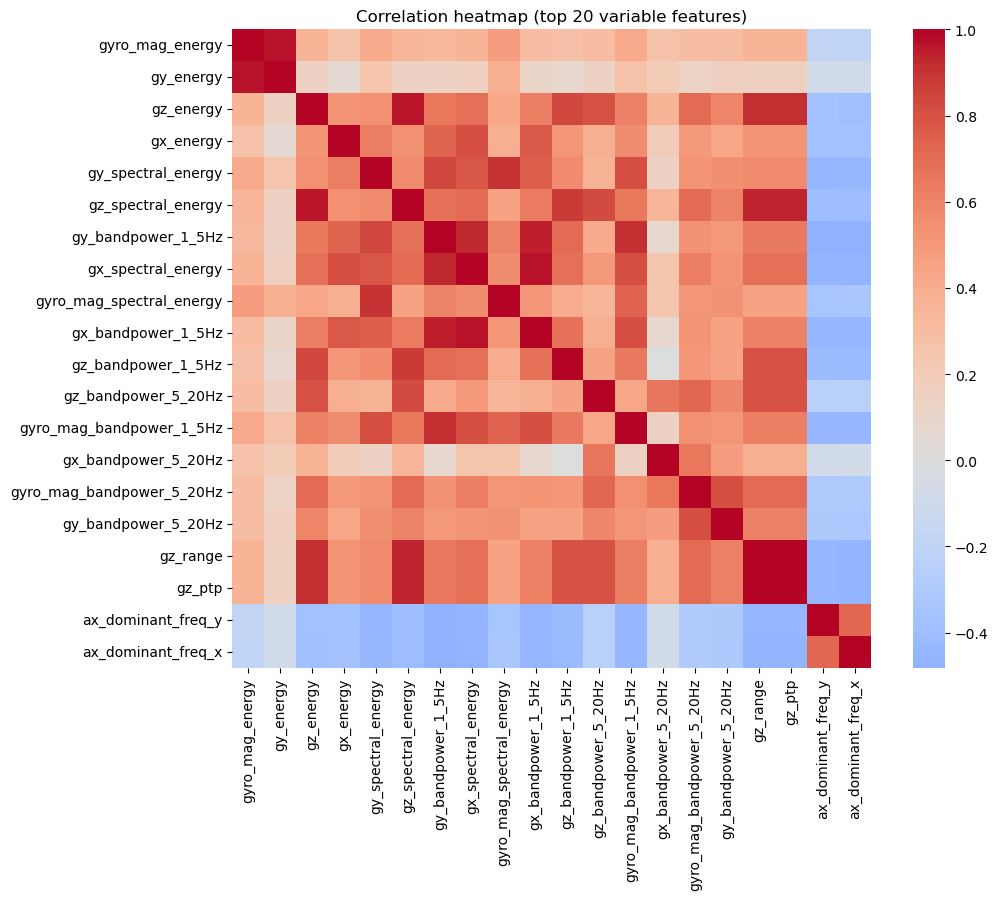

Top 15 absolute correlations among heatmap features:
         feature_1                feature_2     corr
          gz_range                   gz_ptp 1.000000
   gyro_mag_energy                gy_energy 0.969495
gx_spectral_energy       gx_bandpower_1_5Hz 0.967126
         gz_energy       gz_spectral_energy 0.964001
gy_bandpower_1_5Hz       gx_bandpower_1_5Hz 0.944557
gz_spectral_energy                   gz_ptp 0.939622
gz_spectral_energy                 gz_range 0.939622
gy_bandpower_1_5Hz       gx_spectral_energy 0.925513
         gz_energy                 gz_range 0.910637
         gz_energy                   gz_ptp 0.910637
gy_bandpower_1_5Hz gyro_mag_bandpower_1_5Hz 0.904107
gy_spectral_energy gyro_mag_spectral_energy 0.898596
gz_spectral_energy       gz_bandpower_1_5Hz 0.873564
gy_spectral_energy       gy_bandpower_1_5Hz 0.836778
         gz_energy       gz_bandpower_1_5Hz 0.833662


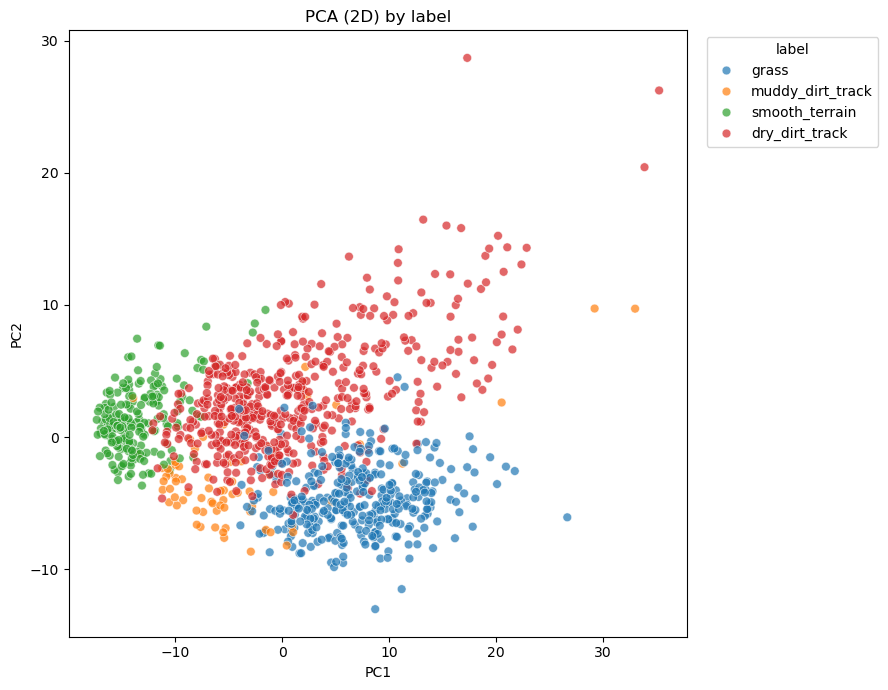

PCA explained variance ratio: [0.37145857 0.09932362]
PCA cumulative explained variance: 0.4707821831750667


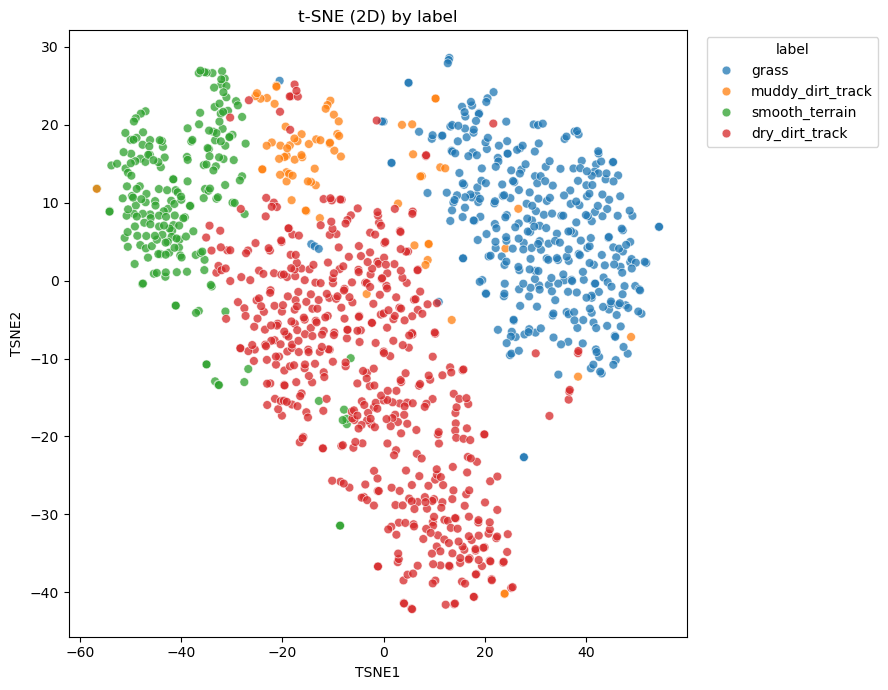

Saved PCA and t-SNE figures to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B
Dataset B evaluation completed.


In [8]:
# ── Dataset B Feature Evaluation (same analysis flow as 06_features) ─────────
reports_dir_a.mkdir(parents=True, exist_ok=True)
reports_dir_b.mkdir(parents=True, exist_ok=True)

viz_features = [
    'acc_mag_rms', 'acc_mag_std', 'acc_mag_energy',
    'gyro_mag_rms', 'az_rms', 'gz_rms',
    'acc_mag_bandpower_5_20Hz', 'gyro_mag_bandpower_5_20Hz'
]

print(f'Dataset A reports directory: {reports_dir_a}')
print(f'Dataset B reports directory: {reports_dir_b}')

dataset_b_eval_outputs = run_feature_evaluation(
    features_df=dataset_B,
    reports_dir=reports_dir_b,
    viz_features=viz_features,
    label_col='label',
    id_cols=ID_COLS,
    top_n_heatmap=TOP_N_HEATMAP,
    random_state=RANDOM_STATE,
    tsne_sample_cap=TSNE_SAMPLE_CAP,
    show=True,
)

print('Dataset B evaluation completed.')

In [9]:
# ── Save outputs ─────────────────────────────────────────────────────────────
output_dir.mkdir(parents=True, exist_ok=True)

path_a = output_dir / 'dataset_A_features.csv'
path_b = output_dir / 'dataset_B_features.csv'

dataset_A.to_csv(path_a, index=False)
dataset_B.to_csv(path_b, index=False)

# ── Final summary ─────────────────────────────────────────────────────────────
final_feat_cols = [c for c in dataset_A.columns if c not in ID_COLS]

print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print(f'Total feature columns in output:  {len(final_feat_cols)}')
print()
print('Dataset A — sample count per class:')
print(dataset_A['label'].value_counts().sort_index().to_string())
print()
print('Dataset B — sample count per class:')
print(dataset_B['label'].value_counts().sort_index().to_string())
print()
print('Saved files:')
print(f'  {path_a}')
print(f'  {path_b}')

FINAL SUMMARY
Total feature columns in output:  240

Dataset A — sample count per class:
label
dry_dirt_track      652
grass               386
muddy_dirt_track    145
smooth_terrain      546

Dataset B — sample count per class:
label
dry_dirt_track      523
grass               354
muddy_dirt_track     75
smooth_terrain      208

Saved files:
  /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/processed/dataset_A_features.csv
  /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/processed/dataset_B_features.csv
